In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
train_data = pd.read_csv(
    "train_fraud_balanced.csv"
)

validation_data = pd.read_csv(
    "validation_fraud.csv"
)

print("Training dataset:", train_data.shape)
print("Validation dataset:", validation_data.shape)

Training dataset: (79328, 45)
Validation dataset: (8648, 45)


In [3]:
if "is_fraud" not in train_data.columns:
    raise ValueError(
        "is_fraud column is missing from training data."
    )

if "is_fraud" not in validation_data.columns:
    raise ValueError(
        "is_fraud column is missing from validation data."
    )

print("Target column found successfully!")

Target column found successfully!


In [4]:
X_train = train_data.drop(
    columns=["is_fraud"]
)

y_train = train_data["is_fraud"]

X_validation = validation_data.drop(
    columns=["is_fraud"]
)

y_validation = validation_data["is_fraud"]

In [5]:
common_columns = [
    column for column in X_train.columns
    if column in X_validation.columns
]

if len(common_columns) == 0:
    raise ValueError(
        "No common features were found."
    )

X_train = X_train[common_columns].copy()
X_validation = X_validation[common_columns].copy()

print("Common features:", len(common_columns))

Common features: 44


In [6]:
for column in common_columns:

    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce"
    )

    X_validation[column] = pd.to_numeric(
        X_validation[column],
        errors="coerce"
    )

print("Features converted to numeric.")

Features converted to numeric.


In [7]:
usable_columns = [
    column for column in X_train.columns
    if X_train[column].notna().any()
]

if len(usable_columns) == 0:
    raise ValueError(
        "No usable numeric features were found."
    )

X_train = X_train[usable_columns].copy()
X_validation = X_validation[usable_columns].copy()

print("Usable features:", len(usable_columns))
print(usable_columns)

Usable features: 22
['amount', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'transaction_hour', 'transaction_day', 'transaction_month', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'login_attempts', 'account_age_days', 'email_age_days', 'failed_payment_attempts', 'customer_balance', 'distance_from_home_km', 'transactions_last_1h', 'new_device', 'new_location']


In [8]:
y_train = pd.to_numeric(
    y_train,
    errors="coerce"
)

y_validation = pd.to_numeric(
    y_validation,
    errors="coerce"
)

valid_train_rows = y_train.notna()
valid_validation_rows = y_validation.notna()

X_train = X_train.loc[
    valid_train_rows
].reset_index(drop=True)

y_train = y_train.loc[
    valid_train_rows
].astype(int).reset_index(drop=True)

X_validation = X_validation.loc[
    valid_validation_rows
].reset_index(drop=True)

y_validation = y_validation.loc[
    valid_validation_rows
].astype(int).reset_index(drop=True)

print("Training classes:")
print(y_train.value_counts())

print("\nValidation classes:")
print(y_validation.value_counts())

Training classes:
is_fraud
0    39664
1    39664
Name: count, dtype: int64

Validation classes:
is_fraud
0    8499
1     149
Name: count, dtype: int64


In [9]:
training_medians = X_train.median()

X_train = X_train.fillna(
    training_medians
)

X_validation = X_validation.fillna(
    training_medians
)

X_train = X_train.fillna(0)
X_validation = X_validation.fillna(0)

print(
    "Training missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Validation missing values:",
    X_validation.isnull().sum().sum()
)

Training missing values: 0
Validation missing values: 0


In [10]:
X_train_normal = X_train[
    y_train == 0
].copy()

print(
    "Normal transactions used for training:",
    X_train_normal.shape
)

Normal transactions used for training: (39664, 22)


In [11]:
scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(
    X_train_normal
)

X_validation_scaled = scaler.transform(
    X_validation
)

print("Feature scaling completed!")

Feature scaling completed!


In [12]:
isolation_model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    max_samples="auto",
    random_state=42,
    n_jobs=1
)

print("Isolation Forest model created!")

Isolation Forest model created!


In [13]:
isolation_model.fit(
    X_train_normal_scaled
)

print("Isolation Forest trained successfully!")

Isolation Forest trained successfully!


In [14]:
validation_anomaly_scores = (
    -isolation_model.decision_function(
        X_validation_scaled
    )
)

print("Anomaly scores created successfully!")

Anomaly scores created successfully!


In [15]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        validation_anomaly_scores
    )
)

f1_values = (
    2 * precision_values[:-1] * recall_values[:-1]
) / (
    precision_values[:-1] +
    recall_values[:-1] +
    1e-10
)

best_threshold_index = np.argmax(
    f1_values
)

best_threshold = thresholds[
    best_threshold_index
]

print(
    "Best anomaly threshold:",
    round(float(best_threshold), 4)
)

print(
    "Best validation F1:",
    round(float(f1_values[best_threshold_index]), 4)
)

Best anomaly threshold: -0.1275
Best validation F1: 0.037


In [16]:
isolation_predictions = (
    validation_anomaly_scores >= best_threshold
).astype(int)

print("Predictions created successfully!")

Predictions created successfully!


In [17]:
isolation_accuracy = accuracy_score(
    y_validation,
    isolation_predictions
)

isolation_precision = precision_score(
    y_validation,
    isolation_predictions,
    zero_division=0
)

isolation_recall = recall_score(
    y_validation,
    isolation_predictions,
    zero_division=0
)

isolation_f1 = f1_score(
    y_validation,
    isolation_predictions,
    zero_division=0
)

isolation_roc_auc = roc_auc_score(
    y_validation,
    validation_anomaly_scores
)

print("ISOLATION FOREST RESULTS")
print("------------------------")
print("Accuracy:", round(isolation_accuracy, 4))
print("Precision:", round(isolation_precision, 4))
print("Recall:", round(isolation_recall, 4))
print("F1 Score:", round(isolation_f1, 4))
print("ROC-AUC:", round(isolation_roc_auc, 4))

ISOLATION FOREST RESULTS
------------------------
Accuracy: 0.2298
Precision: 0.0189
Recall: 0.8591
F1 Score: 0.037
ROC-AUC: 0.5031


In [18]:
print(
    classification_report(
        y_validation,
        isolation_predictions,
        labels=[0, 1],
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.99      0.22      0.36      8499
       Fraud       0.02      0.86      0.04       149

    accuracy                           0.23      8648
   macro avg       0.50      0.54      0.20      8648
weighted avg       0.97      0.23      0.35      8648



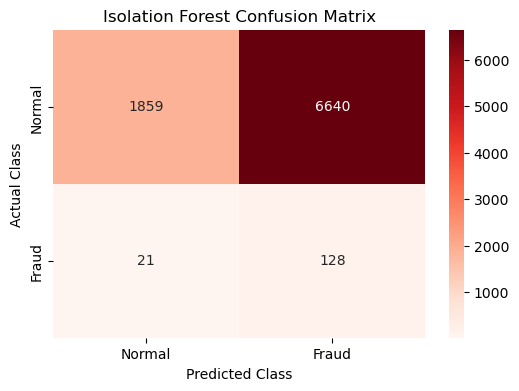

In [19]:
isolation_confusion = confusion_matrix(
    y_validation,
    isolation_predictions,
    labels=[0, 1]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    isolation_confusion,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

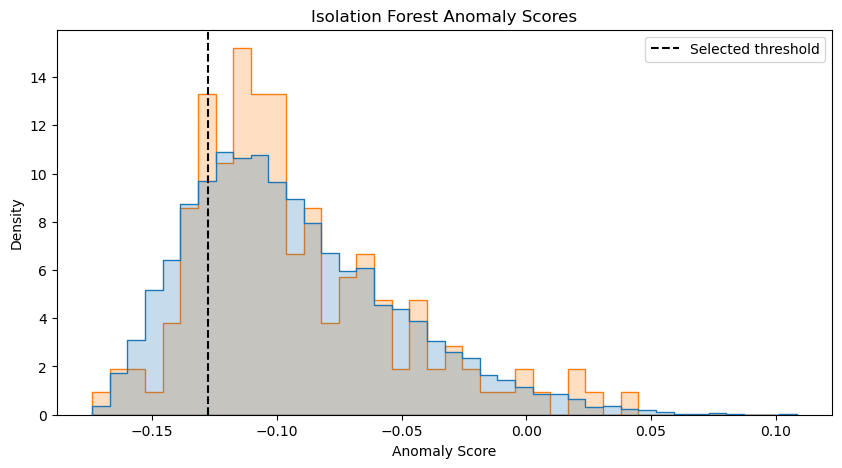

In [20]:
score_data = pd.DataFrame({
    "anomaly_score": validation_anomaly_scores,
    "actual_class": y_validation.map({
        0: "Normal",
        1: "Fraud"
    })
})

plt.figure(figsize=(10, 5))

sns.histplot(
    data=score_data,
    x="anomaly_score",
    hue="actual_class",
    bins=40,
    element="step",
    stat="density",
    common_norm=False
)

plt.axvline(
    best_threshold,
    color="black",
    linestyle="--",
    label="Selected threshold"
)

plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.legend()
plt.show()

In [21]:
isolation_results = pd.DataFrame({
    "model": ["Isolation Forest"],
    "accuracy": [isolation_accuracy],
    "precision": [isolation_precision],
    "recall": [isolation_recall],
    "f1_score": [isolation_f1],
    "roc_auc": [isolation_roc_auc],
    "threshold": [best_threshold]
})

isolation_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc,threshold
0,Isolation Forest,0.2298,0.0189,0.8591,0.037,0.5031,-0.1275


In [22]:
isolation_validation_results = pd.DataFrame({
    "actual_fraud": y_validation,
    "predicted_fraud": isolation_predictions,
    "anomaly_score": validation_anomaly_scores
})

isolation_validation_results.to_csv(
    "isolation_forest_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [23]:
isolation_results.to_csv(
    "isolation_forest_results.csv",
    index=False
)

print("Isolation Forest results saved successfully!")

Isolation Forest results saved successfully!


In [24]:
import os

comparison_file = "final_fraud_model_comparison.csv"

if os.path.exists(comparison_file):

    previous_results = pd.read_csv(
        comparison_file
    )

    previous_results.columns = (
        previous_results.columns
        .str.strip()
        .str.lower()
    )

    comparison_columns = [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]

    final_comparison = pd.concat(
        [
            previous_results[comparison_columns],
            isolation_results[comparison_columns]
        ],
        ignore_index=True
    )

else:

    final_comparison = isolation_results[[
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]].copy()

final_comparison = final_comparison.drop_duplicates(
    subset=["model"],
    keep="last"
)

final_comparison.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Optimized XGBoost,0.9085,0.0603,0.2953,0.1001,0.6272
1,Random Forest,0.8784,0.0552,0.3758,0.0962,0.6506
2,Decision Tree,0.8484,0.0468,0.4027,0.0839,0.6140
3,XGBoost,0.8392,0.0407,0.3691,0.0733,0.6465
4,Logistic Regression Baseline,0.6895,0.0314,0.5705,0.0595,0.6556
5,SVM,0.6950,0.0313,0.5570,0.0592,0.6550
6,Isolation Forest,0.2298,0.0189,0.8591,0.0370,0.5031


In [25]:
final_comparison.to_csv(
    "model_comparison_with_isolation_forest.csv",
    index=False
)

print("Updated model comparison saved successfully!")

Updated model comparison saved successfully!
